In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
df = pd.read_csv("/content/student_performance_data.csv")

In [ ]:
df.head()

,student_id,gender,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,internet_access,extra_classes,parent_education,sleep_hours,overall_score,grade
0,100000,Male,4.54,69.98,36.47,70.70,53.10,17.96,Yes,No,Master,8.09,52.3480,D
1,100001,Female,5.26,84.80,34.25,27.92,87.17,11.29,No,Yes,Bachelor,4.73,53.9485,D
2,100002,Male,8.69,73.76,72.29,70.92,99.61,76.10,No,Yes,PhD,8.73,82.0375,B
3,100003,Male,4.06,45.00,97.63,31.73,88.85,33.55,No,No,Bachelor,8.22,66.4110,C
4,100004,Male,8.83,51.13,65.19,78.28,54.23,88.99,No,No,Bachelor,8.59,65.6005,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             10000 non-null  int64  
 1   gender                 10000 non-null  object 
 2   study_hours_per_day    10000 non-null  float64
 3   attendance_percentage  10000 non-null  float64
 4   assignment_score       10000 non-null  float64
 5   midterm_score          10000 non-null  float64
 6   final_exam_score       10000 non-null  float64
 7   participation_score    10000 non-null  float64
 8   internet_access        10000 non-null  object 
 9   extra_classes          10000 non-null  object 
 10  parent_education       10000 non-null  object 
 11  sleep_hours            10000 non-null  float64
 12  overall_score          10000 non-null  float64
 13  grade                  10000 non-null  object 
dtypes: float64(8), int64(1), object(5)
memory usage: 1.1+ M

In [ ]:
df.describe()

,student_id,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,104999.50000,5.467825,70.493817,64.717809,62.322568,64.979987,55.103202,6.505165,63.826901
std,2886.89568,2.594134,17.295607,20.052779,21.710555,20.216141,25.955949,1.458246,10.230977
min,100000.00000,1.000000,40.000000,30.000000,25.000000,30.010000,10.000000,4.000000,33.263500
25%,102499.75000,3.220000,55.640000,47.320000,43.515000,47.400000,32.955000,5.220000,56.528125
50%,104999.50000,5.420000,70.780000,64.770000,62.050000,65.210000,55.055000,6.520000,63.780750
75%,107499.25000,7.740000,85.200000,81.760000,81.227500,82.500000,77.760000,7.792500,71.163125
max,109999.00000,10.000000,100.000000,99.990000,100.000000,100.000000,99.990000,9.000000,96.879500


In [ ]:
df.isnull().sum()

,0
student_id,0
gender,0
study_hours_per_day,0
attendance_percentage,0
assignment_score,0
midterm_score,0
final_exam_score,0
participation_score,0
internet_access,0
extra_classes,0


In [ ]:
df.drop("student_id", axis=1, inplace=True)

In [ ]:
X = df.drop("grade", axis=1)
y = df["grade"]

In [ ]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [ ]:
categorical_cols = X.select_dtypes(include=["object"]).columns
print(categorical_cols)

Index(['gender', 'internet_access', 'extra_classes', 'parent_education'], dtype='object')


In [ ]:
X = pd.get_dummies(X, columns=categorical_cols)

In [ ]:
X

,study_hours_per_day,attendance_percentage,assignment_score,midterm_score,final_exam_score,participation_score,sleep_hours,overall_score,gender_Female,gender_Male,internet_access_No,internet_access_Yes,extra_classes_No,extra_classes_Yes,parent_education_Bachelor,parent_education_High School,parent_education_Master,parent_education_PhD
0,4.54,69.98,36.47,70.70,53.10,17.96,8.09,52.3480,False,True,False,True,True,False,False,False,True,False
1,5.26,84.80,34.25,27.92,87.17,11.29,4.73,53.9485,True,False,True,False,False,True,True,False,False,False
2,8.69,73.76,72.29,70.92,99.61,76.10,8.73,82.0375,False,True,True,False,False,True,False,False,False,True
3,4.06,45.00,97.63,31.73,88.85,33.55,8.22,66.4110,False,True,True,False,True,False,True,False,False,False
4,8.83,51.13,65.19,78.28,54.23,88.99,8.59,65.6005,False,True,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,6.86,59.65,60.41,39.51,66.43,44.97,8.56,55.6720,True,False,False,True,False,True,False,True,False,False
9996,2.60,83.62,62.45,48.96,81.40,45.11,4.21,66.0930,False,True,False,True,False,True,True,False,False,False
9997,1.46,95.40,67.08,51.51,87.58,65.49,4.72,73.0355,True,False,False,True,True,False,True,False,False,False
9998,7.15,78.24,97.73,46.51,75.49,61.21,5.28,71.5400,True,False,True,False,True,False,True,False,False,False


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [ ]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 5)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
input_size = X_train.shape[1]

model = MLP(input_size)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [ ]:
train_losses = []
test_losses = []

train_accuracies = []
test_accuracies = []

In [ ]:
epochs = 30

for epoch in range(epochs):

    # ================= TRAIN =================
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # ================= TEST =================
    model.eval()

    running_test_loss = 0
    correct_test = 0
    total_test = 0

    with torch.no_grad():

        for inputs, labels in test_loader:

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total_test += labels.size(0)

            correct_test += (predicted == labels).sum().item()

    test_loss = running_test_loss / len(test_loader)
    test_accuracy = correct_test / total_test

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    # ================= PRINT =================
    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Train Acc: {train_accuracy:.4f} "
          f"Test Loss: {test_loss:.4f} "
          f"Test Acc: {test_accuracy:.4f}")

Epoch [1/30] Train Loss: 0.5302 Train Acc: 0.8546 Test Loss: 0.2571 Test Acc: 0.9260
Epoch [2/30] Train Loss: 0.1870 Train Acc: 0.9444 Test Loss: 0.1482 Test Acc: 0.9575
Epoch [3/30] Train Loss: 0.1225 Train Acc: 0.9567 Test Loss: 0.1186 Test Acc: 0.9555
Epoch [4/30] Train Loss: 0.0951 Train Acc: 0.9656 Test Loss: 0.1014 Test Acc: 0.9555
Epoch [5/30] Train Loss: 0.0776 Train Acc: 0.9714 Test Loss: 0.0950 Test Acc: 0.9605
Epoch [6/30] Train Loss: 0.0734 Train Acc: 0.9712 Test Loss: 0.0795 Test Acc: 0.9700
Epoch [7/30] Train Loss: 0.0619 Train Acc: 0.9766 Test Loss: 0.0769 Test Acc: 0.9700
Epoch [8/30] Train Loss: 0.0537 Train Acc: 0.9805 Test Loss: 0.0792 Test Acc: 0.9670
Epoch [9/30] Train Loss: 0.0533 Train Acc: 0.9795 Test Loss: 0.0964 Test Acc: 0.9600
Epoch [10/30] Train Loss: 0.0466 Train Acc: 0.9836 Test Loss: 0.0733 Test Acc: 0.9715
Epoch [11/30] Train Loss: 0.0439 Train Acc: 0.9835 Test Loss: 0.0692 Test Acc: 0.9735
Epoch [12/30] Train Loss: 0.0471 Train Acc: 0.9810 Test Loss: 0

In [ ]:
print("Final Test Accuracy:", test_accuracies[-1])

Final Test Accuracy: 0.9765


In [ ]:
from sklearn.metrics import classification_report

model.eval()

with torch.no_grad():

    outputs = model(X_test)

    _, predicted = torch.max(outputs, 1)

print(classification_report(
    y_test,
    predicted
))

              precision    recall  f1-score   support

           0       0.96      0.77      0.86        31
           1       0.97      0.99      0.98       541
           2       0.98      0.98      0.98      1015
           3       0.97      0.97      0.97       401
           4       1.00      0.58      0.74        12

    accuracy                           0.98      2000
   macro avg       0.98      0.86      0.91      2000
weighted avg       0.98      0.98      0.98      2000



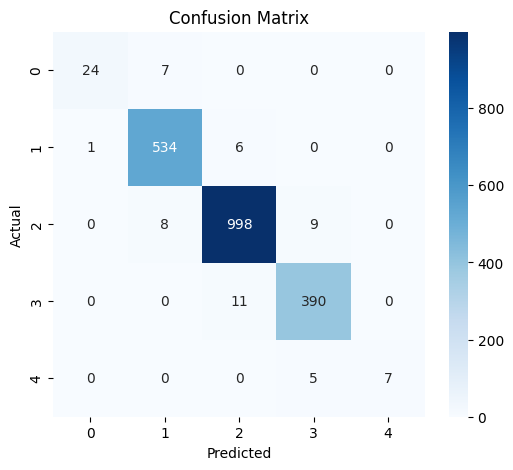

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

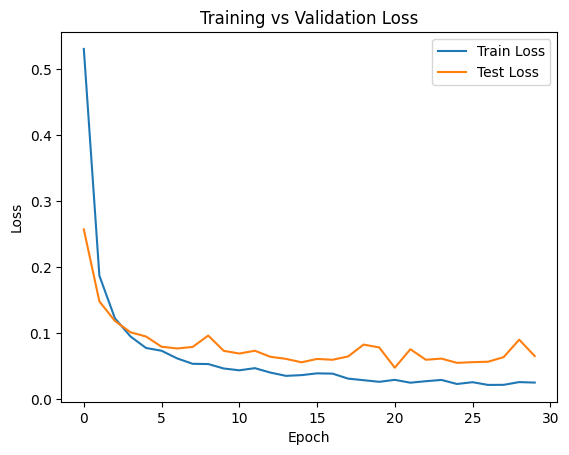

In [ ]:
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

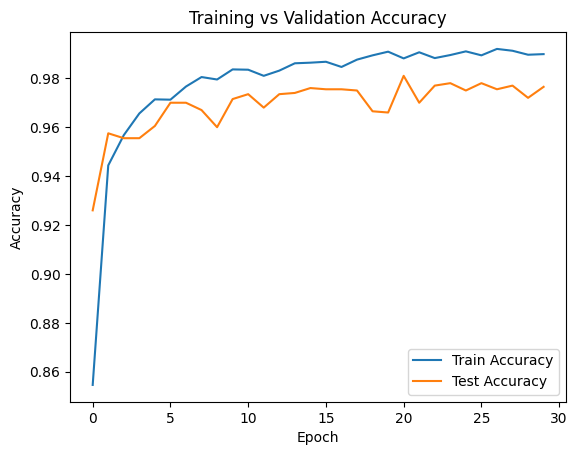

In [ ]:
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.show()

In [ ]:
class MLP(nn.Module):

    def __init__(self, input_size, activation="relu", dropout=False):

        super(MLP, self).__init__()

        # Activation اختيارية
        if activation == "relu":
            act = nn.ReLU()

        elif activation == "tanh":
            act = nn.Tanh()

        layers = [

            nn.Linear(input_size, 128),
            act
        ]

        # Dropout اختياري
        if dropout:
            layers.append(nn.Dropout(0.3))

        layers.extend([

            nn.Linear(128, 64),
            act,

            nn.Linear(64, 5)
        ])

        self.model = nn.Sequential(*layers)

    def forward(self, x):

        return self.model(x)

In [ ]:
def train_model(model, epochs=30):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=0.001
    )

    train_losses = []
    test_losses = []

    train_accs = []
    test_accs = []

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for inputs, labels in train_loader:

            optimizer.zero_grad()

            outputs = model(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # ===== TEST =====
        model.eval()

        running_test_loss = 0
        correct_test = 0
        total_test = 0

        with torch.no_grad():

            for inputs, labels in test_loader:

                outputs = model(inputs)

                loss = criterion(outputs, labels)

                running_test_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                total_test += labels.size(0)

                correct_test += (predicted == labels).sum().item()

        test_loss = running_test_loss / len(test_loader)
        test_acc = correct_test / total_test

        test_losses.append(test_loss)
        test_accs.append(test_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Acc: {train_acc:.4f} "
              f"Test Acc: {test_acc:.4f}")

    return train_losses, test_losses, train_accs, test_accs

In [ ]:
model_relu = MLP(
    input_size=X_train.shape[1],
    activation="relu",
    dropout=False
)

relu_results = train_model(model_relu)

Epoch [1/30] Train Acc: 0.8423 Test Acc: 0.9390
Epoch [2/30] Train Acc: 0.9414 Test Acc: 0.9355
Epoch [3/30] Train Acc: 0.9549 Test Acc: 0.9615
Epoch [4/30] Train Acc: 0.9669 Test Acc: 0.9605
Epoch [5/30] Train Acc: 0.9710 Test Acc: 0.9695
Epoch [6/30] Train Acc: 0.9726 Test Acc: 0.9660
Epoch [7/30] Train Acc: 0.9788 Test Acc: 0.9680
Epoch [8/30] Train Acc: 0.9800 Test Acc: 0.9685
Epoch [9/30] Train Acc: 0.9804 Test Acc: 0.9670
Epoch [10/30] Train Acc: 0.9805 Test Acc: 0.9735
Epoch [11/30] Train Acc: 0.9839 Test Acc: 0.9680
Epoch [12/30] Train Acc: 0.9855 Test Acc: 0.9720
Epoch [13/30] Train Acc: 0.9862 Test Acc: 0.9720
Epoch [14/30] Train Acc: 0.9884 Test Acc: 0.9745
Epoch [15/30] Train Acc: 0.9832 Test Acc: 0.9675
Epoch [16/30] Train Acc: 0.9871 Test Acc: 0.9770
Epoch [17/30] Train Acc: 0.9890 Test Acc: 0.9740
Epoch [18/30] Train Acc: 0.9881 Test Acc: 0.9730
Epoch [19/30] Train Acc: 0.9899 Test Acc: 0.9705
Epoch [20/30] Train Acc: 0.9892 Test Acc: 0.9735
Epoch [21/30] Train Acc: 0.98

In [ ]:
model_tanh = MLP(
    input_size=X_train.shape[1],
    activation="tanh",
    dropout=False
)

tanh_results = train_model(model_tanh)

Epoch [1/30] Train Acc: 0.8902 Test Acc: 0.9545
Epoch [2/30] Train Acc: 0.9550 Test Acc: 0.9510
Epoch [3/30] Train Acc: 0.9634 Test Acc: 0.9690
Epoch [4/30] Train Acc: 0.9694 Test Acc: 0.9610
Epoch [5/30] Train Acc: 0.9714 Test Acc: 0.9750
Epoch [6/30] Train Acc: 0.9766 Test Acc: 0.9670
Epoch [7/30] Train Acc: 0.9809 Test Acc: 0.9770
Epoch [8/30] Train Acc: 0.9791 Test Acc: 0.9795
Epoch [9/30] Train Acc: 0.9832 Test Acc: 0.9760
Epoch [10/30] Train Acc: 0.9780 Test Acc: 0.9715
Epoch [11/30] Train Acc: 0.9830 Test Acc: 0.9750
Epoch [12/30] Train Acc: 0.9846 Test Acc: 0.9770
Epoch [13/30] Train Acc: 0.9841 Test Acc: 0.9775
Epoch [14/30] Train Acc: 0.9861 Test Acc: 0.9750
Epoch [15/30] Train Acc: 0.9861 Test Acc: 0.9805
Epoch [16/30] Train Acc: 0.9879 Test Acc: 0.9830
Epoch [17/30] Train Acc: 0.9841 Test Acc: 0.9800
Epoch [18/30] Train Acc: 0.9890 Test Acc: 0.9875
Epoch [19/30] Train Acc: 0.9822 Test Acc: 0.9820
Epoch [20/30] Train Acc: 0.9871 Test Acc: 0.9810
Epoch [21/30] Train Acc: 0.98

In [ ]:
model_dropout = MLP(
    input_size=X_train.shape[1],
    activation="relu",
    dropout=True
)

dropout_results = train_model(model_dropout)

Epoch [1/30] Train Acc: 0.7917 Test Acc: 0.9415
Epoch [2/30] Train Acc: 0.8985 Test Acc: 0.9310
Epoch [3/30] Train Acc: 0.9129 Test Acc: 0.9520
Epoch [4/30] Train Acc: 0.9203 Test Acc: 0.9430
Epoch [5/30] Train Acc: 0.9283 Test Acc: 0.9600
Epoch [6/30] Train Acc: 0.9360 Test Acc: 0.9460
Epoch [7/30] Train Acc: 0.9376 Test Acc: 0.9600
Epoch [8/30] Train Acc: 0.9394 Test Acc: 0.9635
Epoch [9/30] Train Acc: 0.9467 Test Acc: 0.9575
Epoch [10/30] Train Acc: 0.9459 Test Acc: 0.9595
Epoch [11/30] Train Acc: 0.9477 Test Acc: 0.9630
Epoch [12/30] Train Acc: 0.9509 Test Acc: 0.9650
Epoch [13/30] Train Acc: 0.9575 Test Acc: 0.9565
Epoch [14/30] Train Acc: 0.9605 Test Acc: 0.9620
Epoch [15/30] Train Acc: 0.9577 Test Acc: 0.9585
Epoch [16/30] Train Acc: 0.9601 Test Acc: 0.9700
Epoch [17/30] Train Acc: 0.9639 Test Acc: 0.9705
Epoch [18/30] Train Acc: 0.9625 Test Acc: 0.9660
Epoch [19/30] Train Acc: 0.9633 Test Acc: 0.9715
Epoch [20/30] Train Acc: 0.9666 Test Acc: 0.9670
Epoch [21/30] Train Acc: 0.96

In [ ]:
results = {

    "Model": [
        "ReLU",
        "Tanh",
        "ReLU + Dropout"
    ],

    "Final Test Accuracy": [

        relu_results[3][-1],
        tanh_results[3][-1],
        dropout_results[3][-1]
    ]
}

results_df = pd.DataFrame(results)

print(results_df)

            Model  Final Test Accuracy
0            ReLU               0.9725
1            Tanh               0.9815
2  ReLU + Dropout               0.9730


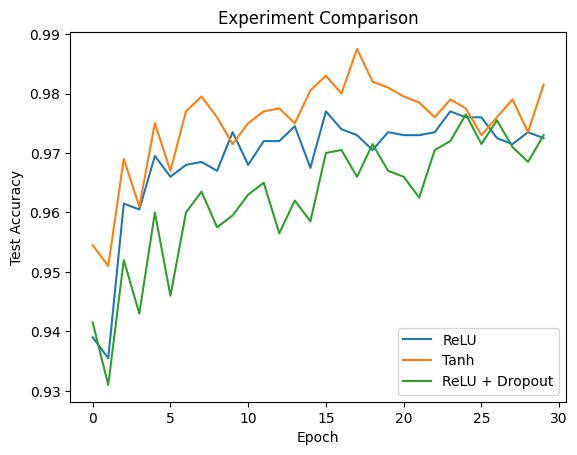

In [ ]:
plt.plot(relu_results[3], label="ReLU")

plt.plot(tanh_results[3], label="Tanh")

plt.plot(dropout_results[3], label="ReLU + Dropout")

plt.xlabel("Epoch")

plt.ylabel("Test Accuracy")

plt.title("Experiment Comparison")

plt.legend()

plt.show()